# SpaBound — Mouse embryo: RNA + ATAC

This example keeps the source notebook's active preprocessing, graph and training settings. This is a runnable workflow example, not a claim of exact paper-table reproduction.

Provide your own paired H5AD files; data and previously generated results are not included. Install the package and notebook dependencies as described in the repository README, including R/mclust for clustering. Run all cells in order from a fresh kernel. Data layout and configuration notes are in [examples/README.md](README.md).

## 1. Imports, seeds and paths

In [1]:
import os
import random
import sys
from pathlib import Path

# Locate the source checkout before importing SpaBound.
# Also support Jupyter launched from the parent workspace containing SpaBound/.
cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for parent in (cwd, *cwd.parents)
        for candidate in (parent, parent / 'SpaBound')
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'spabound' / '__init__.py').is_file()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(
        'Start Jupyter in the SpaBound repository, its examples/ directory, '
        'or the parent workspace containing SpaBound/.'
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score, homogeneity_score,
)

from spabound.preprocessing import pca, lsi, clr_normalize_each_cell
from spabound.graph_v2 import construct_boundary_aware_graphs_v2
from spabound.trainer import SpaBound
from spabound.utils import clustering


def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def configured_root(variable, default_folder):
    value = Path(os.environ.get(variable, default_folder)).expanduser()
    return value if value.is_absolute() else REPO_ROOT / value


DATA_ROOT = configured_root('SPABOUND_DATA_DIR', 'data')
OUTPUT_ROOT = configured_root('SPABOUND_OUTPUT_DIR', 'outputs')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PREPROCESS_SEED = 42
setup_seed(PREPROCESS_SEED)

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\_metadata.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Configuration and paired inputs

`SPABOUND_DATA_DIR` selects a root containing the dataset subfolders; it defaults to `data/` in the repository. `SPABOUND_OUTPUT_DIR` defaults to `outputs/`. Relative environment-variable paths are resolved from the repository root.

The inputs must have raw counts in `X`, matching unique spot identifiers in the same order, and spatial coordinates in `obsm['spatial']`. Reference labels are optional and are used only for the metric/plot cells here. Cluster counts are explicit example settings. The trainer seed is 2022; preprocessing uses 42 and the mclust helper uses R seed 2020.

In [2]:
DATASET = 'mouse_embryo'
DATA_DIR = DATA_ROOT / DATASET
OUTPUT_DIR = OUTPUT_ROOT / DATASET
RNA_PATH = DATA_DIR / 's1_adata_rna.h5ad'
MODALITY2_PATH = DATA_DIR / 's1_adata_atac.h5ad'
REFERENCE_KEY = 'Joint_clusters'
N_CLUSTERS = 14

GRAPH_CONFIG = {
    'n_neighbors_spatial': 6,
    'sigma_spatial': None,
    'beta_spatial': 0.8,
    'spatial_candidates_k': 40,
    'n_neighbors_feature': 15,
    'beta_feature': 0.6,
    'verbose': True,
}

TRAINING_CONFIG = {
    'datatype': 'SPOTS',
    'learning_rate': 0.0002,
    'weight_decay': 0.0001,
    'dim_output': 160,
    'z_dim': 64,
    'n_latent_shared': 32,
    'n_latent_private': 16,
    'mmvae_weight': 1.0,
    'reconstruction_weight': 1.0,
    'kl_weight': 0.005,
    'edge_preserving_weight': 0.0001,
    'use_appnp': True,
    'appnp_hidden': 128,
    'appnp_layers': 2,
    'appnp_alpha': 0.25,
    'appnp_residual': True,
    'appnp_dropout': 0.0,
    'use_boundary_aware_graph': True,
    'use_edge_preserving_loss': True,
    'edge_preserving_type': 'charbonnier',
    'epochs': 300,
    'random_seed': 2022,
}

In [3]:
for input_path in (RNA_PATH, MODALITY2_PATH):
    if not input_path.is_file():
        raise FileNotFoundError(
            f'Missing {input_path}. Supply the paired H5AD data; see examples/README.md.'
        )
rna_raw = sc.read_h5ad(RNA_PATH)
modality2_raw = sc.read_h5ad(MODALITY2_PATH)
rna_raw.var_names_make_unique()
modality2_raw.var_names_make_unique()
if not rna_raw.obs_names.is_unique or not modality2_raw.obs_names.is_unique:
    raise ValueError('Spot identifiers must be unique in both modalities.')
if not rna_raw.obs_names.equals(modality2_raw.obs_names):
    raise ValueError('The two H5AD files must contain the same spots in the same order.')
for adata, name in ((rna_raw, 'RNA'), (modality2_raw, 'second modality')):
    if 'spatial' not in adata.obsm:
        raise ValueError(f'{name} requires coordinates in obsm["spatial"].')
    if not np.isfinite(np.asarray(adata.obsm['spatial'])).all():
        raise ValueError(f'{name} spatial coordinates must be finite.')
print(f'Loaded {rna_raw.n_obs} paired spots; device: {DEVICE}')

Loaded 2186 paired spots; device: cuda


## 3. Modality-specific preprocessing

In [4]:
# Reset from fresh-loaded objects so this cell can be rerun safely.
setup_seed(PREPROCESS_SEED)
adata_omics1 = rna_raw.copy()
adata_omics2 = modality2_raw.copy()

sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor='seurat_v3', n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)
adata_high = adata_omics1[:, adata_omics1.var['highly_variable']]

# Retain the source notebook's RNA PCA dimension rule.
adata_omics1.obsm['feat'] = pca(adata_high, n_comps=min(50, adata_omics2.n_vars - 1))
# Reuse supplied LSI if present; otherwise calculate 51 components and drop the first.
if 'X_lsi' not in adata_omics2.obsm:
    sc.pp.highly_variable_genes(adata_omics2, flavor='seurat_v3', n_top_genes=3000)
    lsi(adata_omics2, use_highly_variable=False, n_components=51)
adata_omics2.obsm['feat'] = adata_omics2.obsm['X_lsi'].copy()

E:\code\shared-private-multimodalVAE-main\SpaBound\spabound\preprocessing.py:209: RuntimeWarning: divide by zero encountered in divide
  idf = X.shape[0] / X.sum(axis=0)


## 4. Boundary-aware graph construction

In [5]:
setup_seed(PREPROCESS_SEED)
graphs = construct_boundary_aware_graphs_v2(
    adata_omics1, adata_omics2, **GRAPH_CONFIG
)
data = {'adata_omics1': adata_omics1, 'adata_omics2': adata_omics2}
for key in (
    'adj_spatial_omics1', 'adj_spatial_omics2',
    'adj_feature_omics1', 'adj_feature_omics2',
):
    data[key] = graphs[key]
data['edge_gradients'] = graphs.get('edge_gradients')

Boundary-Aware Graph Construction V2 (Continuous Gradient-Based)
  N cells: 2186
  Spatial graph: k=6, sigma=auto, beta=0.8
  Feature graph: candidates=40, k=15, beta=0.6

----------------------------------------------------------------------
Step 1: Compute Fused Features
----------------------------------------------------------------------
  Fused features: 50 + 50 = 100 dims

----------------------------------------------------------------------
Step 2: Spatial Graphs (Continuous Gradient Penalty)
----------------------------------------------------------------------

Omics 1 - Spatial graph:
   Adaptive sigma_spatial: 1.0000
  Spatial graph V2: 2186 nodes, 13116 directed edges (7776 undirected)
   sigma_spatial: 1.0000, beta: 0.8000
   Median gradient: 11.1215, 80th percentile: 1.1814, 90th percentile: 1.2957
   Edges above median gradient: 50.0%
   Edges above 80th percentile: 20.0%
   Edges above 90th percentile: 10.0%
   Mean weight before attenuation: 0.3708
   Mean weight aft

## 5. Train SpaBound

In [6]:
setup_seed(PREPROCESS_SEED)
trainer = SpaBound(data=data, device=DEVICE, **TRAINING_CONFIG)
output = trainer.train()

Converting adjacency matrices to dense tensors...
 Adjacency matrices converted to dense tensors
Edge-preserving loss enabled: charbonnier (weight=0.0001)
Initializing SpaBound with APPNP encoders...
  APPNP hidden dim: 128
  APPNP layers: 2
  APPNP alpha: 0.25
  APPNP residual: True
  APPNP dropout: 0.0
Using APPNP encoders for enhanced long-range dependency capture

Training SpaBound with 300 epochs...
Encoder type: APPNP
MMVAE latent dims: shared=32, private=16
Private reconstruction: False


 21%|██        | 62/300 [00:00<00:02, 89.67it/s]

Epoch 50/300
  Recon Loss (omics1): 7.7623
  Recon Loss (omics2): 0.9987
  KL Loss: 0.4487
  KL Weight (annealed): 0.0024
  MMVAE Loss: 0.0011
  Edge-Preserving Loss: 7610.3433
  Total Loss: 9.5231


 39%|███▊      | 116/300 [00:01<00:01, 99.60it/s]

Epoch 100/300
  Recon Loss (omics1): 5.7405
  Recon Loss (omics2): 0.9717
  KL Loss: 56.9454
  KL Weight (annealed): 0.0050
  MMVAE Loss: 0.2819
  Edge-Preserving Loss: 8198.9727
  Total Loss: 7.8140


...

Epoch 200/300
  Recon Loss (omics1): 4.2365
  Recon Loss (omics2): 0.9132
  KL Loss: 66.0580
  KL Weight (annealed): 0.0050
  MMVAE Loss: 0.3303
  Edge-Preserving Loss: 8481.8828
  Total Loss: 6.3282


 88%|████████▊ | 265/300 [00:02<00:00, 99.39it/s] 

Epoch 250/300
  Recon Loss (omics1): 3.8253
  Recon Loss (omics2): 0.8924
  KL Loss: 71.6764
  KL Weight (annealed): 0.0050
  MMVAE Loss: 0.3584
  Edge-Preserving Loss: 8071.7783
  Total Loss: 5.8833


100%|██████████| 300/300 [00:03<00:00, 93.09it/s] 

Epoch 300/300
  Recon Loss (omics1): 3.5485
  Recon Loss (omics2): 0.8823
  KL Loss: 74.6285
  KL Weight (annealed): 0.0050
  MMVAE Loss: 0.3731
  Edge-Preserving Loss: 7823.8906
  Total Loss: 5.5863
Model training finished!



## 6. Cluster the shared representation

`output['SpaBound']` contains the row-normalized shared posterior-mean representation. Clustering applies PCA20 followed by mclust with the stated cluster count. Auxiliary private coordinates are not interpreted as validated modality-specific biological factors.

In [7]:
setup_seed(PREPROCESS_SEED)
result = adata_omics1.copy()
result.obsm['SpaBound'] = output['SpaBound']
clustering(
    result, key='SpaBound', add_key='SpaBound',
    n_clusters=N_CLUSTERS, method='mclust', use_pca=True, n_comps=20,
)
result.obs['SpaBound'] = result.obs['SpaBound'].astype('category')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


## 7. Evaluate and visualize

ARI, NMI, AMI and homogeneity do not require aligning cluster identifiers. Missing reference labels are excluded from metrics and the evaluated count is reported. Predictions are not relabeled against the reference.

In [8]:
metrics = {'n_spots': int(result.n_obs)}
if REFERENCE_KEY in result.obs:
    valid = result.obs[REFERENCE_KEY].notna() & result.obs['SpaBound'].notna()
    metrics['n_evaluated'] = int(valid.sum())
    if not valid.any():
        raise ValueError('No spots have both reference and predicted labels.')
    truth = result.obs.loc[valid, REFERENCE_KEY].astype(str)
    prediction = result.obs.loc[valid, 'SpaBound'].astype(str)
    metrics.update(
        ARI=adjusted_rand_score(truth, prediction),
        NMI=normalized_mutual_info_score(truth, prediction),
        AMI=adjusted_mutual_info_score(truth, prediction),
        homogeneity=homogeneity_score(truth, prediction),
    )
else:
    print(f'No {REFERENCE_KEY!r} column: skipping reference-label metrics.')
pd.Series(metrics, name=DATASET)

n_spots        2186.000000
n_evaluated    2186.000000
ARI               0.479513
NMI               0.615588
AMI               0.608822
homogeneity       0.615290
Name: mouse_embryo, dtype: float64

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages

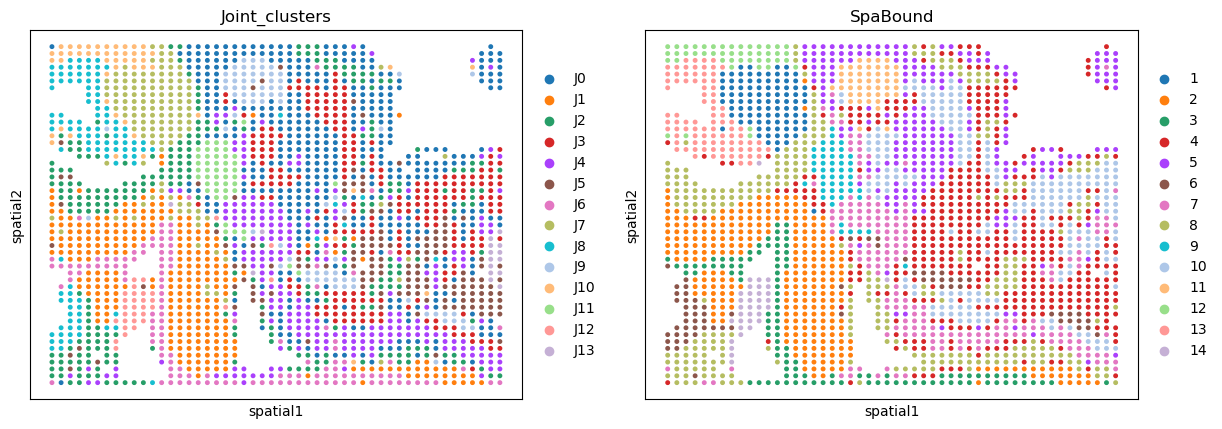

In [10]:
sc.pl.embedding(result, basis='spatial', color=colors, size=50)

## 8. Save outputs

Write a separate result H5AD, cluster labels, metrics and the settings used for this run. Input H5AD files are never overwritten. Rerunning this cell replaces the example's previous files in its output subfolder.

In [ ]:
import json

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Preserve the input RNA matrix; add results to a separate output file.
export = rna_raw.copy()
export.obs['SpaBound'] = result.obs['SpaBound'].astype(str).to_numpy()
export.obsm['SpaBound'] = result.obsm['SpaBound'].copy()
export.obsm['X_umap_SpaBound'] = result.obsm['X_umap'].copy()
export.write_h5ad(OUTPUT_DIR / 'spabound_result.h5ad')
result.obs[['SpaBound']].to_csv(OUTPUT_DIR / 'clusters.csv', index_label='spot_id')
pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / 'metrics.csv', index=False)
configuration = {
    'dataset': DATASET,
    'preprocess_seed': PREPROCESS_SEED,
    'mclust_seed': 2020,
    'n_clusters': N_CLUSTERS,
    'graph': GRAPH_CONFIG,
    'training': TRAINING_CONFIG,
}
(OUTPUT_DIR / 'configuration.json').write_text(
    json.dumps(configuration, indent=2) + '\n', encoding='utf-8'
)
print(f'Results saved in {OUTPUT_DIR}')